<a href="https://colab.research.google.com/github/dhanashriekke60-lgtm/Python-Basic-Projects/blob/main/Assignment_no16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving insurance.csv to insurance.csv
User uploaded file "insurance.csv" with length 51380 bytes


In [ ]:
# Q1:i) Load the insurance dataset
filepath = '/content/insurance (1).csv'
df = pd.read_csv(filepath)
print("Insurance Dataset:")
df

Insurance Dataset:


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
#Q1: ii)display the first 10 rows
print("\nFirst 10 rows:")
df.head(10)



First 10 rows:


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [ ]:
# Q2: Display Shape, dataset Information, Statistical Summary.
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(1338, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Statistical Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   93

In [ ]:
print("Null value in each column:\n")
print(df.isnull().sum())

Null value in each column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [ ]:
# Q4: Identify numerical and categorical columns in the dataset.

numerical_columns =  df.select_dtypes(include = ['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_columns.tolist())

categorical_columns = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_columns.tolist())

Numerical Columns:
['age', 'bmi', 'children', 'expenses']

Categorical Columns:
['sex', 'smoker', 'region']


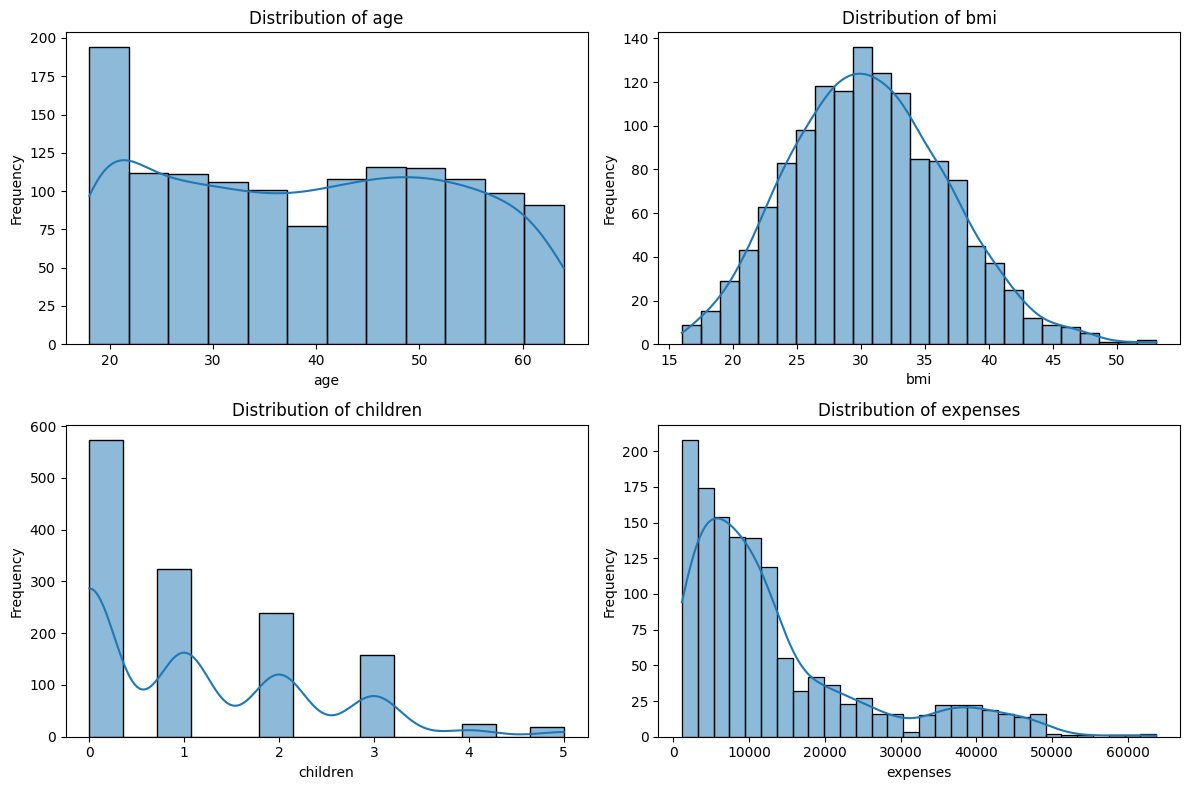

In [ ]:
# Q5: Create distribution plots for all numerical column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")

num_cols = ['age', 'bmi', 'children', 'charges']
df.columns = df.columns.str.strip()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

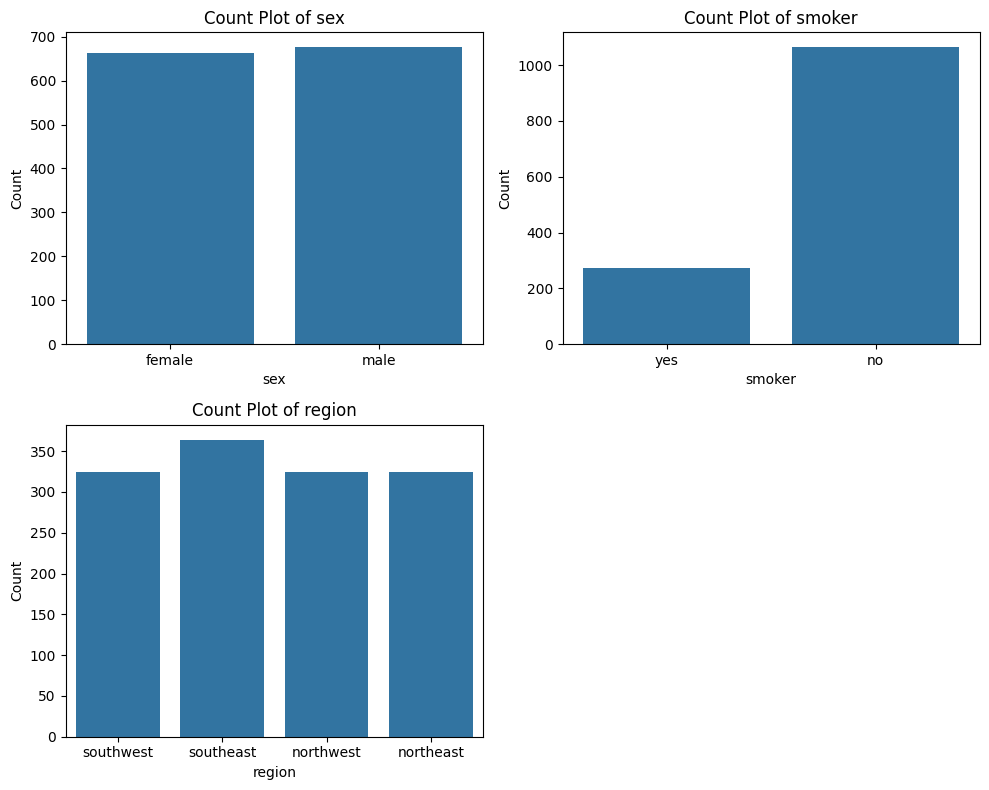

In [ ]:
# Q6. Create count plots for all categorical columns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
cat_cols = ["sex", "smoker", "region"]

plt.figure(figsize=(10, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

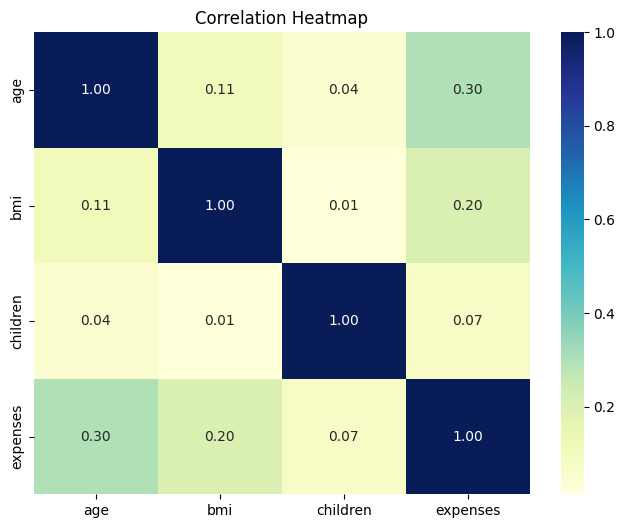

In [ ]:
# Q7: Create a heatmap to show the correlation between numerical variables.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")

# numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation
corr = num_df.corr()

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Q8: Perform analysis on the charges column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
df.columns = df.columns.str.strip()
if "charges" in df.columns:
    charge_col = "charges"
elif "expenses" in df.columns:
    charge_col = "expenses"
else:
    print("Charges/Expenses column not found!")
    print("Available columns:", df.columns.tolist())
    raise SystemExit()

# a) Find the average insurance charges
print("Average Insurance Charges:")
print(df[charge_col].mean())

# b) Find the maximum and minimum charges
print("\nAverage Insurance Charges:")
print(df[charge_col].mean())

# b) Find the maximum and minimum charges
print("\nMaximum Charges:", df[charge_col].max())
print("Minimum Charges:", df[charge_col].min())

# c) Group by smoker and compare average charges
print("\nAverage Charges by Smoker:")
print(df.groupby("smoker")[charge_col].mean())

Average Insurance Charges:
13270.422414050823

Average Insurance Charges:
13270.422414050823

Maximum Charges: 63770.43
Minimum Charges: 1121.87

Average Charges by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


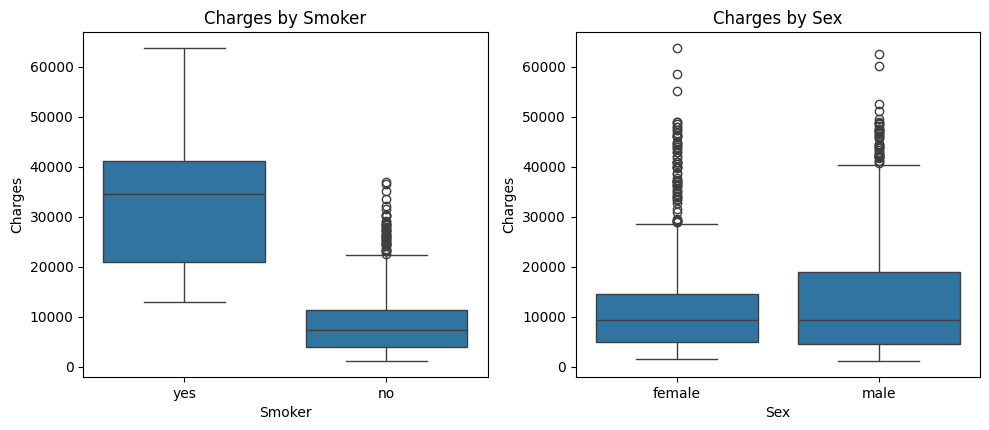

In [ ]:
# Q9: Create a boxplot to show the distribution of charges
# with respect to smoker and sex
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")

df.columns = df.columns.str.strip()

if "charges" in df.columns:
    charge_col = "charges"
elif "expenses" in df.columns:
    charge_col = "expenses"
else:
    print("Charges/Expenses column not found!")
    print(df.columns.tolist())
    raise SystemExit()

plt.figure(figsize=(10,8))

# Boxplot: Charges vs Smoker
plt.subplot(2,2,1)
sns.boxplot(x="smoker", y=charge_col, data=df)
plt.title("Charges by Smoker")
plt.xlabel("Smoker")
plt.ylabel("Charges")

# Boxplot: Charges vs Sex
plt.subplot(2,2,2)
sns.boxplot(x="sex", y=charge_col, data=df)
plt.title("Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")

plt.tight_layout()
plt.show()

In [ ]:
# Q10: Mini Project / Analysis Summary
# import library
import pandas as pd

# read dataset
df = pd.read_csv("insurance.csv")

# remove extra spaces
df.columns = df.columns.str.strip()

# Select charges/expenses column automatically
if "charges" in df.columns:
    charge_col = "charges"
elif "expenses" in df.columns:
    charge_col = "expenses"

# 1.What is the average age and BMI of the customers?
print("Average Age:", round(df["age"].mean(),2))
print("Average BMI:", round(df["bmi"].mean(),2))

# 2.How does smoking affect insurance charges?
print("\nAverage Charges by Smoker:")
print(df.groupby("smoker")[charge_col].mean())

# 3.Which region has the highest number of customers?
print("\nNumber of Customers by Region:")
print(df["region"].value_counts())

print("\nAnalysis Summary")
print("1. Average age and BMI are shown above.")
print("2. Smokers have higher insurance charges than non-smokers.")
print("3. The region with the highest customer count is shown above.")
print("4. The visualizations show that insurance charges vary more for smokers than for non-smokers.")

Average Age: 39.21
Average BMI: 30.67

Average Charges by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64

Number of Customers by Region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Analysis Summary
1. Average age and BMI are shown above.
2. Smokers have higher insurance charges than non-smokers.
3. The region with the highest customer count is shown above.
4. The visualizations show that insurance charges vary more for smokers than for non-smokers.
